# Vector Error Correction Model (VECM) Parameter Estimation With Two Cointegrating Vectors

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf, stats, arima
from lib.plots import comparison, stack, twinx, comparison_stack, curve
from lib.data.impl.stats import OLS

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [2]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_dff(dxt, title):
    labels = [r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"]   
    stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 8))

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.4, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"])

## VECM(1) Two Cointegrating Vectors

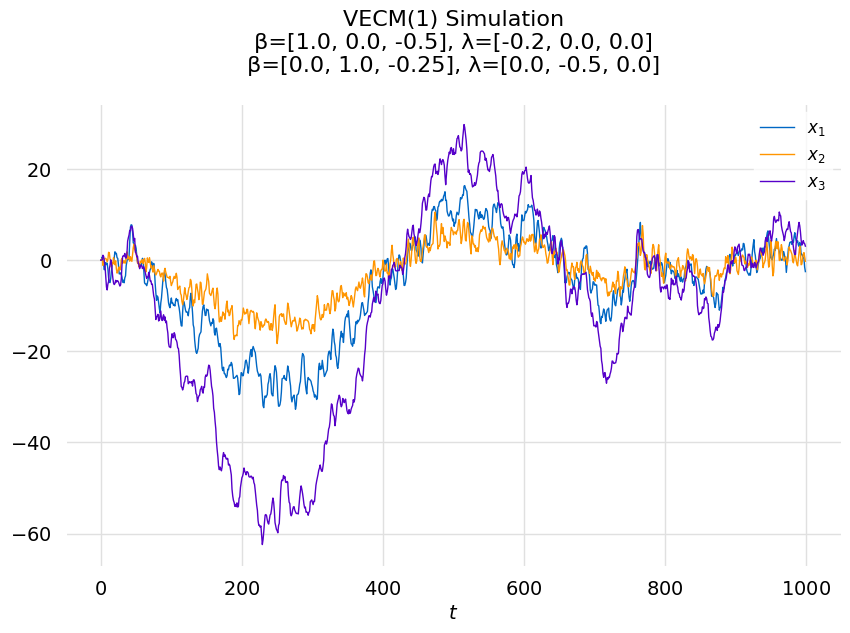

In [3]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(1) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [4]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [5]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


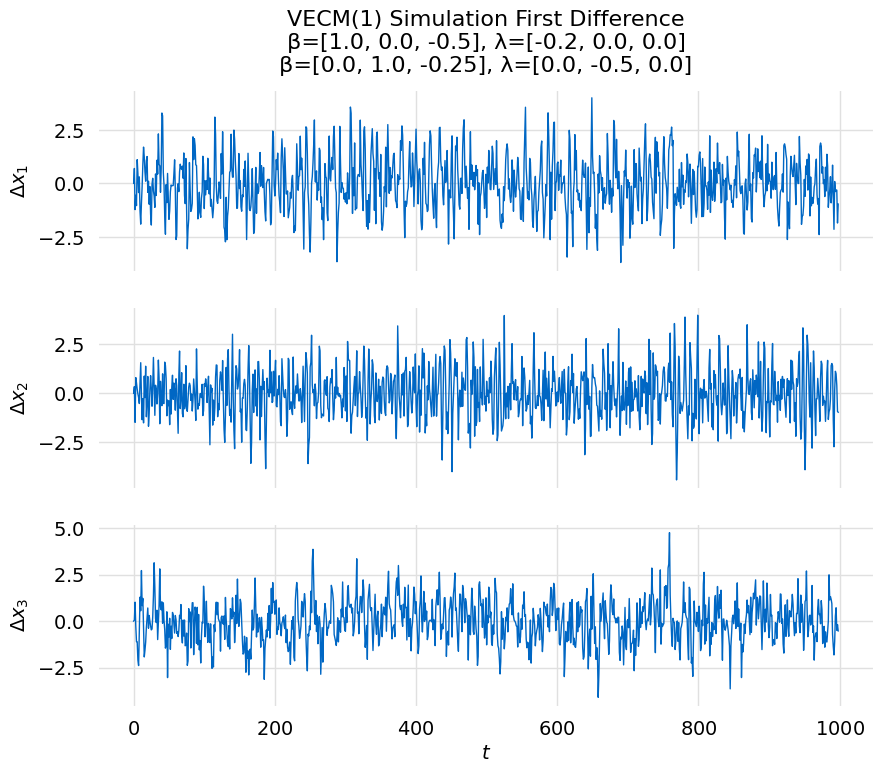

In [6]:
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [7]:
result, result_model = vecm.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.7711,0.8450,2.162,0.7992
1,-0.002678*,0.1156*,0.9973*,0.04228*
2,0.005473,0.1681,1.005,0.06729
3,0.01526,0.2222,1.015,0.09394
4,0.02522,0.2765,1.026,0.1208


In [8]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
   "_VAROrderTestReport__order": {
      "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
      "order": {
         "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.0026783163237235966
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
      "order": {
         "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "d5aee312-0831-4a55-b81c-00af21eb01a3",
     

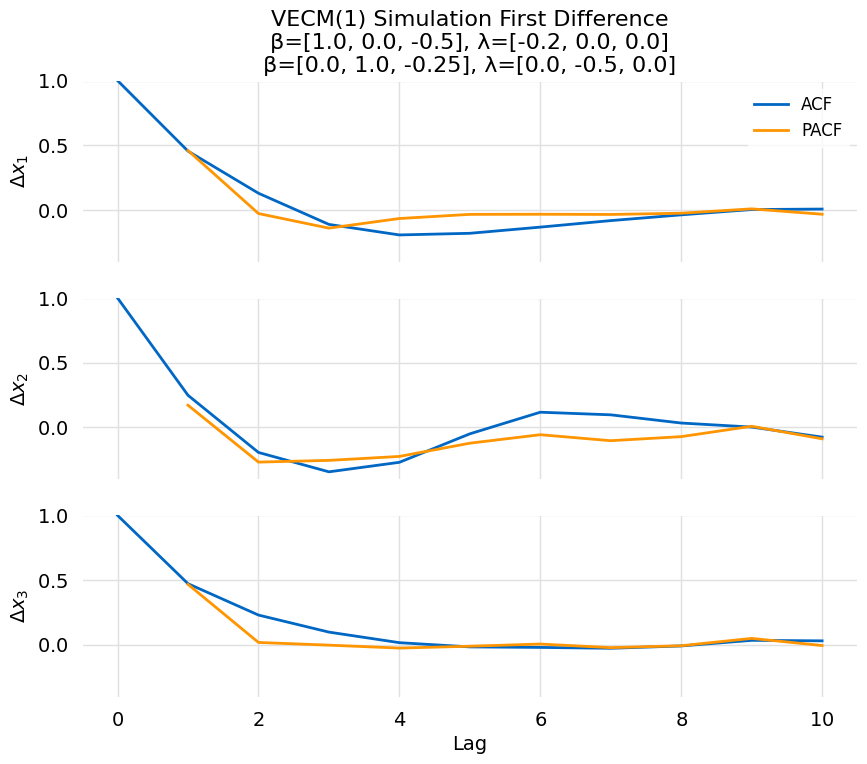

In [9]:
nlags = 10
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [10]:
result, _ = arima.compute_ar_estimate(dxt[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1526.734
Date:                Wed, 20 Dec 2023   AIC                           3059.467
Time:                        09:22:50   BIC                           3074.187
Sample:                             0   HQIC                          3065.062
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0033      0.065     -0.051      0.959      -0.130       0.124
ar.L1          0.4546      0.028     15.978      0.000       0.399       0.510
sigma2         1.2441      0.054     23.184      0.000       1.139       1.349
===================================================================================
Ljung-Box (L1) (Q):                   2.00   Jarque-Bera (JB):                 2.79
Prob(Q):                              0.16   Prob(JB):                         0.25
Heteroskedasticity (H):               0.91   Skew:                             0.10
Prob(H) (two-sided):                  0.40   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
result, _ = arima.compute_ar_estimate(dxt[1], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1617.685
Date:                Wed, 20 Dec 2023   AIC                           3241.369
Time:                        09:22:50   BIC                           3256.089
Sample:                             0   HQIC                          3246.964
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.052     -0.011      0.991      -0.102       0.100
ar.L1          0.2479      0.030      8.293      0.000       0.189       0.306
sigma2         1.4928      0.063     23.511      0.000       1.368       1.617
===================================================================================
Ljung-Box (L1) (Q):                   4.58   Jarque-Bera (JB):                 3.98
Prob(Q):                              0.03   Prob(JB):                         0.14
Heteroskedasticity (H):               1.36   Skew:                             0.11
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
result, _ = arima.compute_ar_estimate(dxt[2], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1422.930
Date:                Wed, 20 Dec 2023   AIC                           2851.860
Time:                        09:22:50   BIC                           2866.580
Sample:                             0   HQIC                          2857.455
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.060      0.044      0.965      -0.115       0.121
ar.L1          0.4718      0.028     17.107      0.000       0.418       0.526
sigma2         1.0106      0.043     23.558      0.000       0.927       1.095
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 2.54
Prob(Q):                              0.91   Prob(JB):                         0.28
Heteroskedasticity (H):               1.03   Skew:                             0.00
Prob(H) (two-sided):                  0.78   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [13]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=259.9578, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.9856  , p=0.0462  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=3.9976  , p=0.0456  , df=1
likelihood ratio test: chi2=3.9897  , p=0.0458  , df=1
parameter F test:         F=3.9856  , p=0.0462  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=27.6388 , p=0.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=27.7221 , p=0.0000  , df=1
likelihood ratio test: chi2=27.3441 , p=0.0000  , df=1
parameter F test:         F=27.6388 , p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0215  , p=0.8834  

In [14]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0462,0.05,True,1,2
3,0.0000,0.05,True,1,3
4,0.8834,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.7309,0.05,False,3,1
8,0.8121,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [15]:
print(result_model.to_json(pretty=True))

{
   "test_id": "9419d0ed-55d5-426d-993c-7a55b03c5835",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "9419d0ed-55d5-426d-993c-7a55b03c5835",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "9419d0ed-55d5-426d-993c-7a55b03c5835",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0462,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "9419d0ed-55d5-426d-993c-7a55b03c5835",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

In [16]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 1)

In [17]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          599.630 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          193.357 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            1.776 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [18]:
print(result_model.to_json(pretty=True))

{
   "test_id": "d59e8aeb-f0c0-44f5-a8c3-0cde21d32dc5",
   "trace_test": [
      {
         "test_id": "d59e8aeb-f0c0-44f5-a8c3-0cde21d32dc5",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 599.6295897285204,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "d59e8aeb-f0c0-44f5-a8c3-0cde21d32dc5",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 193.35738182053223,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```

In [19]:
result, result_model = vecm.compute_estimate(xt, maxlags=1, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0339,0.032,-1.066,0.287,-0.096,0.028
L1.y1,0.4994,0.026,19.318,0.000,0.449,0.550
L1.y2,-0.0084,0.028,-0.302,0.762,-0.063,0.046
L1.y3,0.0158,0.032,0.499,0.618,-0.046,0.078
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0484,0.031,-1.564,0.118,-0.109,0.012
L1.y1,0.0175,0.025,0.695,0.487,-0.032,0.067
L1.y2,0.4588,0.027,16.925,0.000,0.406,0.512
L1.y3,0.0133,0.031,0.432,0.665,-0.047,0.074
,coef,std err,z,P>|z|,[0.025,0.975]


In [20]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.03385489038302104,
         "err": 0.031770913186160044,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "22a5df41-15b2-44e2-9c7a-281f3127b7d8",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.04844566296461681,
         "err": 0.03097078587276602,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "22a5df41-15b2-44e2-9c7a-281f3127b7d8",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.004231518285866733,
         "err": 0.03189550847981663,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "22a5df41-15b2-44e2-9c7a-281f3127b7d8",
         "param_t

In [21]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

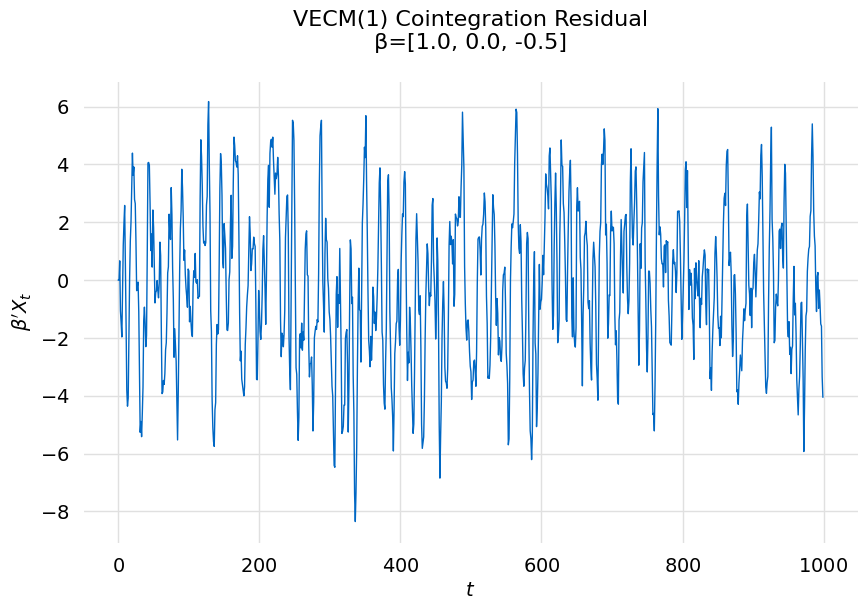

In [22]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [23]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.5415      │
├────────────────┼───────────────┤
│ pvalue         │   5.65437e-21 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


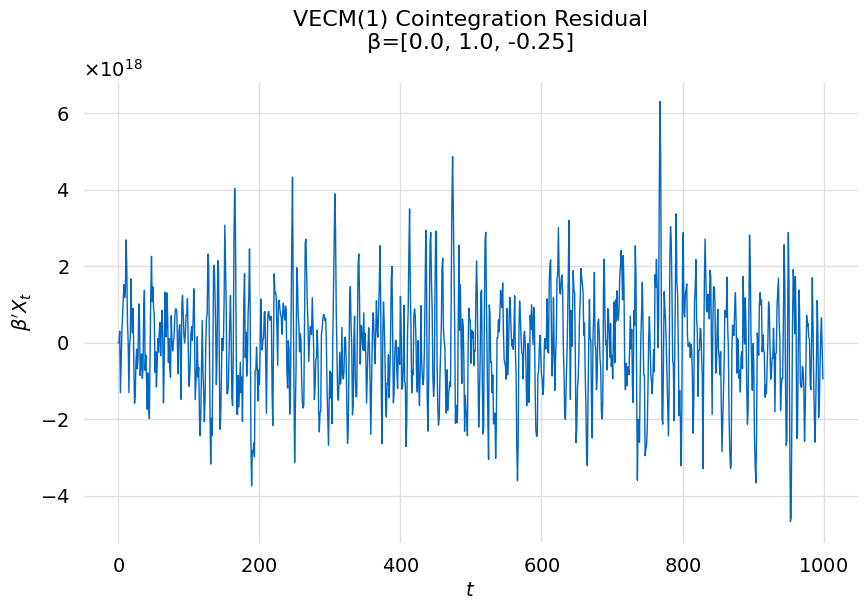

In [24]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [25]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │  -8.23507     │
├────────────────┼───────────────┤
│ pvalue         │   9.53163e-14 │
├────────────────┼───────────────┤
│ Lags           │  12           │
├────────────────┼───────────────┤
│ Number Obs     │ 987           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56801 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94128 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61655 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(2) Two Cointegrating Vectors

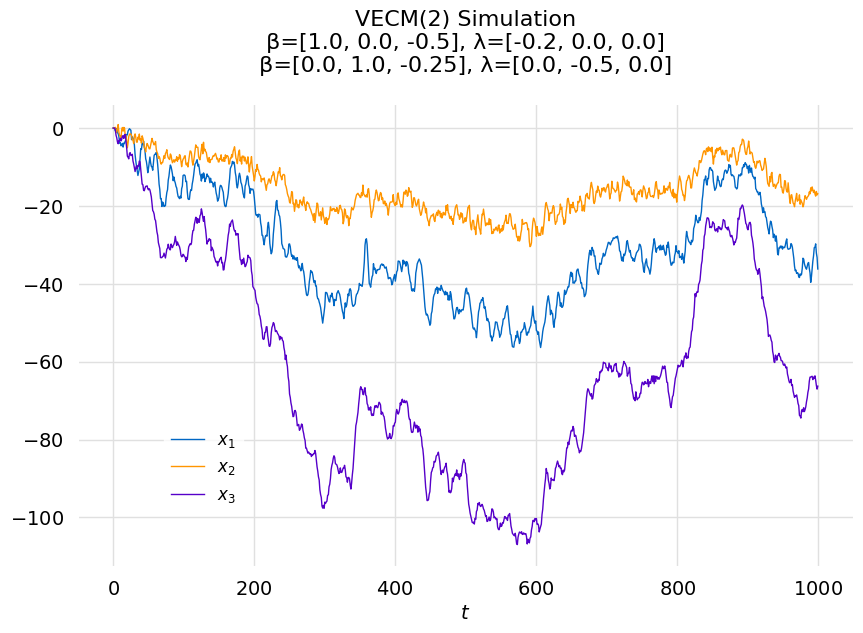

In [26]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(2) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [27]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [28]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


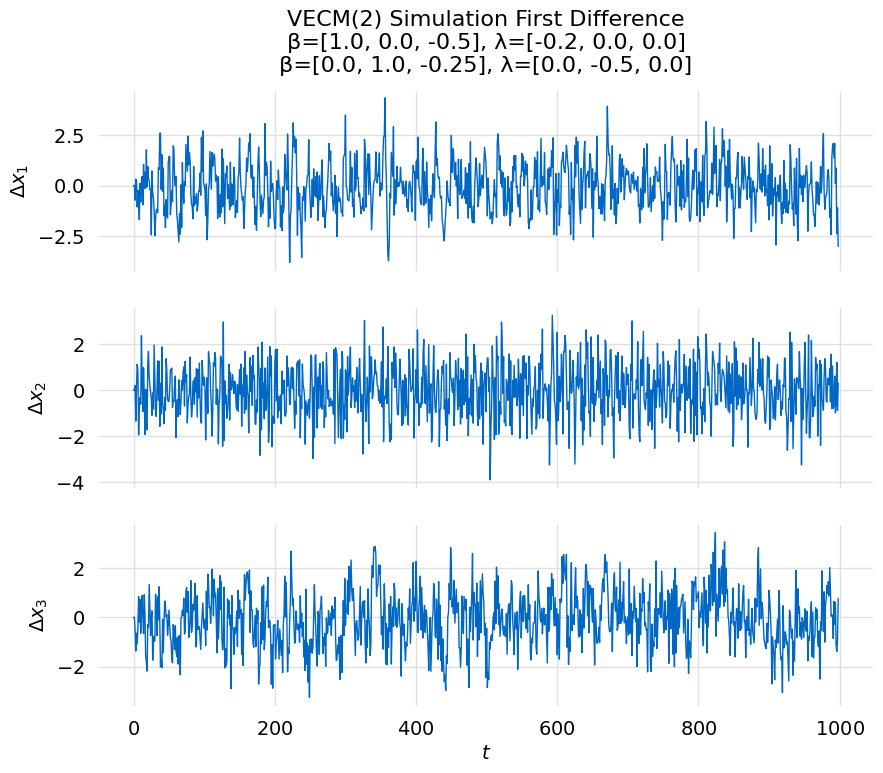

In [29]:
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [30]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.5443,0.6183,1.723,0.5725
1,0.2449,0.3633,1.277,0.2899
2,0.02845*,0.1913*,1.029*,0.09037*
3,0.03182,0.2391,1.032,0.1106
4,0.04529,0.2970,1.046,0.1410
5,0.05019,0.3463,1.051,0.1628
6,0.05808,0.3986,1.060,0.1875


In [31]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
   "_VAROrderTestReport__order": {
      "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
      "order": {
         "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.028451969878069736
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
      "order": {
         "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "05d7a868-c50f-4ca4-82ed-af732b25ab50",
       

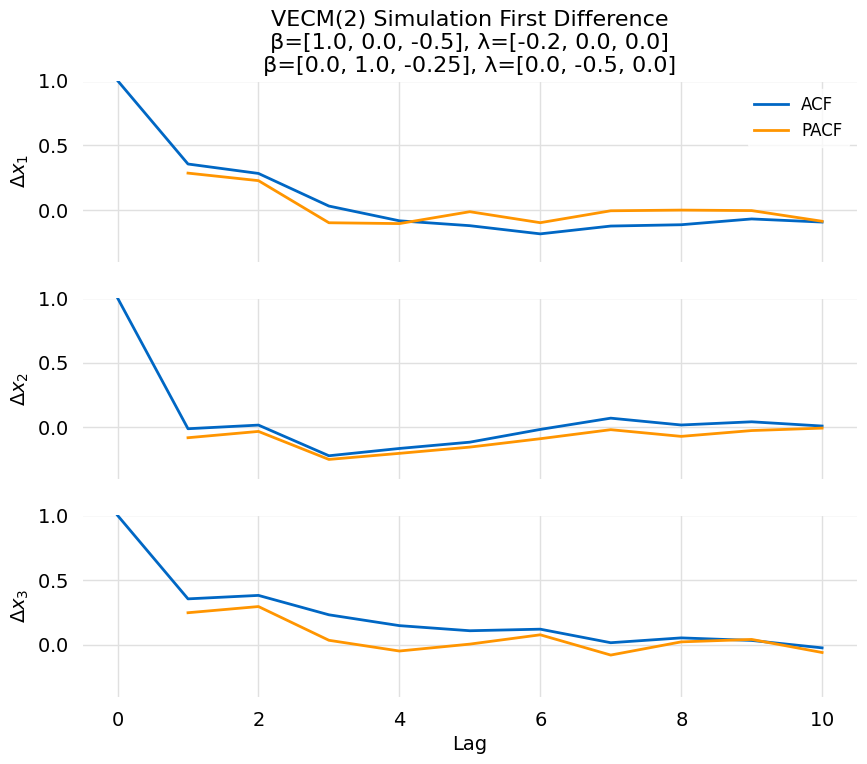

In [32]:
nlags = 10
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [33]:
result, _ = arima.compute_ar_estimate(dxt[0], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1522.324
Date:                Wed, 20 Dec 2023   AIC                           3052.648
Time:                        09:22:52   BIC                           3072.275
Sample:                             0   HQIC                          3060.108
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0392      0.067     -0.586      0.558      -0.170       0.092
ar.L1          0.2931      0.031      9.344      0.000       0.232       0.355
ar.L2          0.1795      0.032      5.602      0.000       0.117       0.242
sigma2         1.2332      0.056     21.901      0.000       1.123       1.344
===================================================================================
Ljung-Box (L1) (Q):                   0.61   Jarque-Bera (JB):                 2.61
Prob(Q):                              0.44   Prob(JB):                         0.27
Heteroskedasticity (H):               0.96   Skew:                             0.12
Prob(H) (two-sided):                  0.72   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
result, _ = arima.compute_ar_estimate(dxt[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1568.812
Date:                Wed, 20 Dec 2023   AIC                           3145.625
Time:                        09:22:52   BIC                           3165.252
Sample:                             0   HQIC                          3153.085
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0169      0.037     -0.455      0.649      -0.090       0.056
ar.L1         -0.0103      0.031     -0.337      0.736      -0.070       0.050
ar.L2          0.0175      0.032      0.549      0.583      -0.045       0.080
sigma2         1.3538      0.065     20.687      0.000       1.225       1.482
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 3.66
Prob(Q):                              0.90   Prob(JB):                         0.16
Heteroskedasticity (H):               1.09   Skew:                            -0.06
Prob(H) (two-sided):                  0.43   Kurtosis:                         2.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
result, _ = arima.compute_ar_estimate(dxt[2], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1421.012
Date:                Wed, 20 Dec 2023   AIC                           2850.023
Time:                        09:22:53   BIC                           2869.650
Sample:                             0   HQIC                          2857.483
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0658      0.069     -0.947      0.343      -0.202       0.070
ar.L1          0.2507      0.030      8.315      0.000       0.192       0.310
ar.L2          0.2922      0.031      9.560      0.000       0.232       0.352
sigma2         1.0067      0.049     20.438      0.000       0.910       1.103
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 4.46
Prob(Q):                              0.72   Prob(JB):                         0.11
Heteroskedasticity (H):               1.08   Skew:                             0.01
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [36]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=144.5630, p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=91.1268 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4271  , p=0.5135  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=0.4284  , p=0.5128  , df=1
likelihood ratio test: chi2=0.4283  , p=0.5128  , df=1
parameter F test:         F=0.4271  , p=0.5135  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7082  , p=0.4928  

In [37]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.4928,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.3733,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.1666,0.05,False,3,1
8,0.1366,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [38]:
print(result_model.to_json(pretty=True))

{
   "test_id": "7a0a5dcc-e2c0-4493-b13b-4c29369d9648",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "7a0a5dcc-e2c0-4493-b13b-4c29369d9648",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "7a0a5dcc-e2c0-4493-b13b-4c29369d9648",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.4928,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "7a0a5dcc-e2c0-4493-b13b-4c29369d9648",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [39]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 2)

In [40]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          459.234 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          183.537 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            5.223 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [41]:
print(result_model.to_json(pretty=True))

{
   "test_id": "faa3d5f6-4891-4e43-8fbd-28ba7368ec31",
   "trace_test": [
      {
         "test_id": "faa3d5f6-4891-4e43-8fbd-28ba7368ec31",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 459.2344284129183,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "faa3d5f6-4891-4e43-8fbd-28ba7368ec31",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 183.53665271328921,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [42]:
result, result_model = vecm.compute_estimate(xt, maxlags=2, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0186,0.031,0.590,0.555,-0.043,0.080
L1.y1,0.2914,0.029,10.146,0.000,0.235,0.348
L1.y2,0.0115,0.030,0.379,0.705,-0.048,0.071
L1.y3,0.0637,0.032,1.990,0.047,0.001,0.127
L2.y1,0.2670,0.029,9.271,0.000,0.211,0.323
L2.y2,0.0199,0.030,0.664,0.507,-0.039,0.079
L2.y3,-0.0379,0.032,-1.168,0.243,-0.102,0.026
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0596,0.032,-1.870,0.061,-0.122,0.003
L1.y1,-0.0581,0.029,-1.999,0.046,-0.115,-0.001


In [43]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": 0.01857346594518569,
         "err": 0.03146897446471549,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "766bce1e-3db1-4da5-af8e-9276a2fb5ff9",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.059579384446280526,
         "err": 0.031860750709684846,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "766bce1e-3db1-4da5-af8e-9276a2fb5ff9",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.023058912709848185,
         "err": 0.032005965150569755,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "766bce1e-3db1-4da5-af8e-9276a2fb5ff9",
         "param_

In [44]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

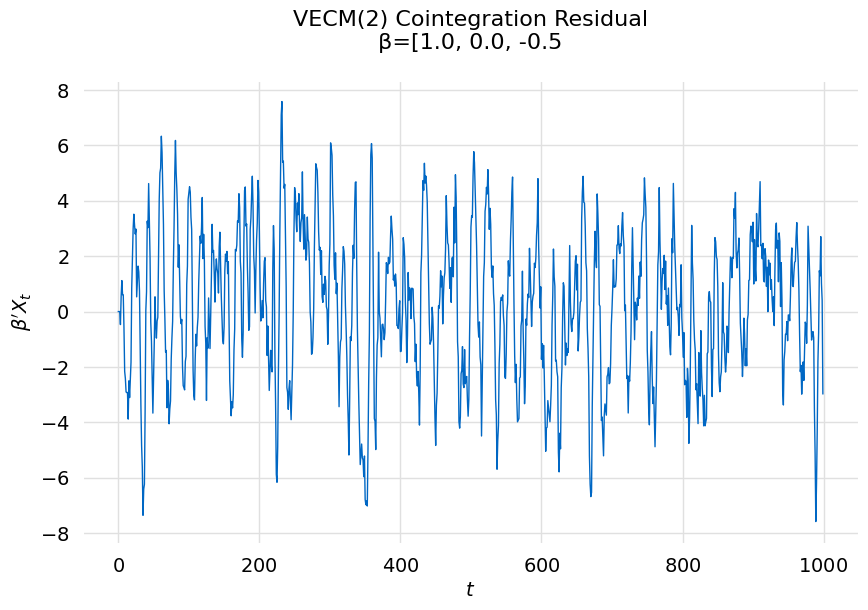

In [45]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(2) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [46]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.0791      │
├────────────────┼───────────────┤
│ pvalue         │   7.92927e-24 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


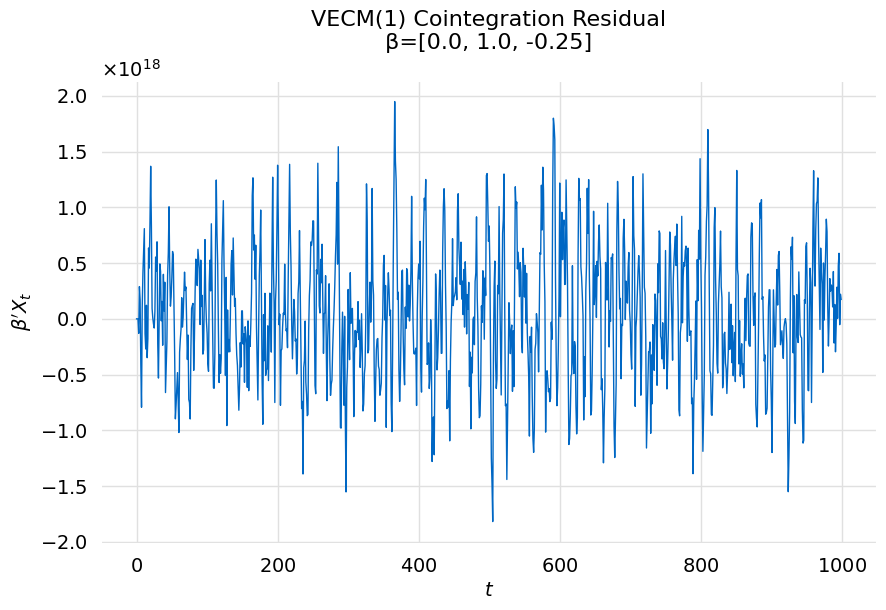

In [47]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [48]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -17.4913      │
├────────────────┼───────────────┤
│ pvalue         │   8.35679e-29 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(3) Two Cointegrating Vectors

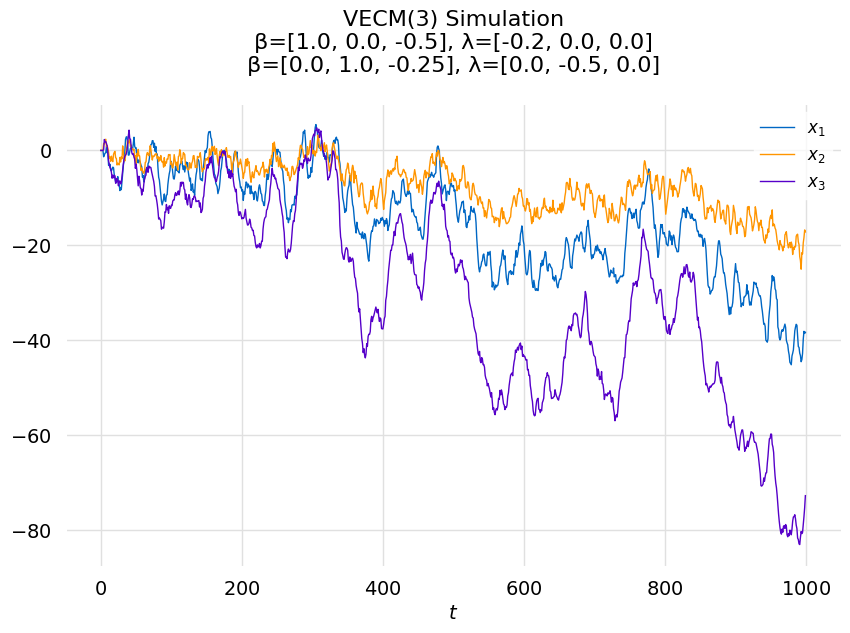

In [49]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(3) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [50]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [51]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


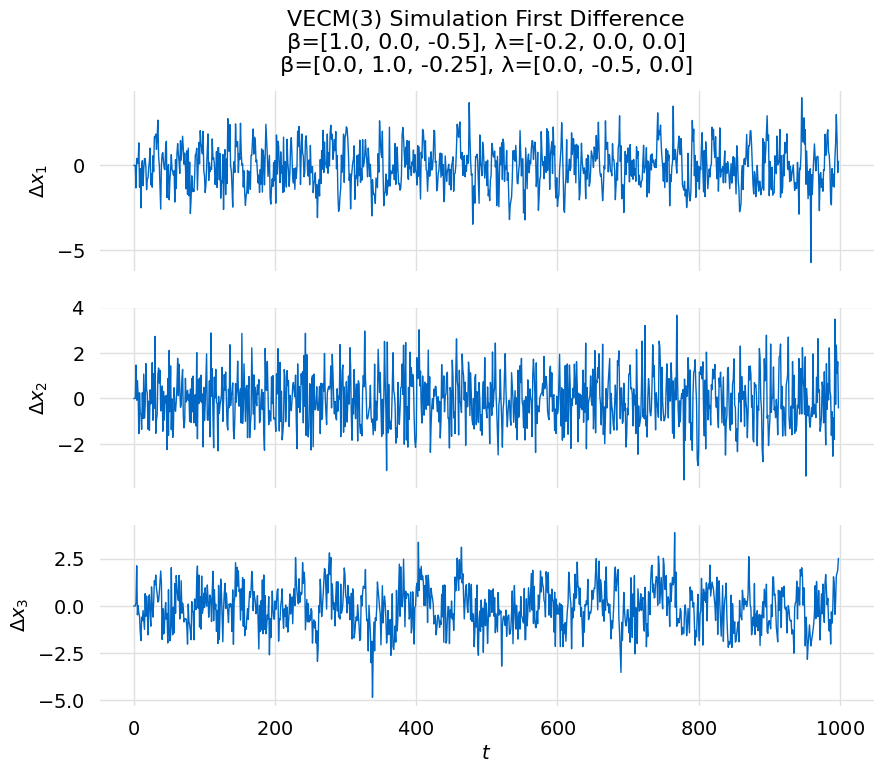

In [52]:
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [53]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.5787,0.6527,1.784,0.6069
1,0.2701,0.3886,1.310,0.3152
2,0.04980,0.2127*,1.051,0.1117
3,0.03267*,0.2400,1.033*,0.1115*
4,0.04221,0.2939,1.043,0.1379
5,0.04343,0.3395,1.044,0.1560
6,0.05544,0.3960,1.057,0.1849


In [54]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
   "_VAROrderTestReport__order": {
      "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
      "order": {
         "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.03267069825872169
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
      "order": {
         "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "4a3821ad-e89d-4758-8603-cbdc59407d0d",
        

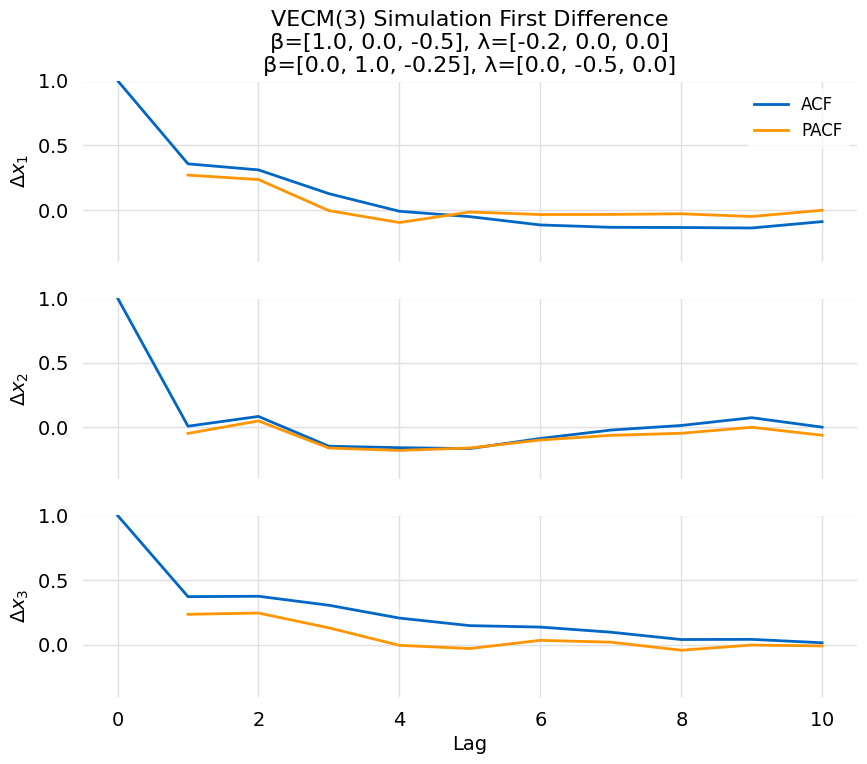

In [55]:
nlags = 10
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [56]:
result, _ = arima.compute_ar_estimate(dxt[0], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1534.953
Date:                Wed, 20 Dec 2023   AIC                           3079.906
Time:                        09:22:55   BIC                           3104.440
Sample:                             0   HQIC                          3089.231
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0383      0.067     -0.571      0.568      -0.170       0.093
ar.L1          0.2904      0.034      8.545      0.000       0.224       0.357
ar.L2          0.2211      0.035      6.260      0.000       0.152       0.290
ar.L3         -0.0430      0.031     -1.371      0.170      -0.104       0.018
sigma2         1.2647      0.053     23.830      0.000       1.161       1.369
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 3.98
Prob(Q):                              0.88   Prob(JB):                         0.14
Heteroskedasticity (H):               1.06   Skew:                            -0.05
Prob(H) (two-sided):                  0.58   Kurtosis:                         3.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [57]:
result, _ = arima.compute_ar_estimate(dxt[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1537.582
Date:                Wed, 20 Dec 2023   AIC                           3085.164
Time:                        09:22:55   BIC                           3109.698
Sample:                             0   HQIC                          3094.489
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0174      0.035     -0.504      0.614      -0.085       0.050
ar.L1          0.0208      0.031      0.663      0.507      -0.041       0.082
ar.L2          0.0856      0.033      2.631      0.009       0.022       0.149
ar.L3         -0.1481      0.031     -4.810      0.000      -0.209      -0.088
sigma2         1.2716      0.060     21.328      0.000       1.155       1.388
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):                 5.09
Prob(Q):                              0.44   Prob(JB):                         0.08
Heteroskedasticity (H):               1.29   Skew:                             0.16
Prob(H) (two-sided):                  0.02   Kurtosis:                         2.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
result, _ = arima.compute_ar_estimate(dxt[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1426.993
Date:                Wed, 20 Dec 2023   AIC                           2863.986
Time:                        09:22:55   BIC                           2888.519
Sample:                             0   HQIC                          2873.311
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0662      0.082     -0.812      0.417      -0.226       0.094
ar.L1          0.2351      0.033      7.203      0.000       0.171       0.299
ar.L2          0.2421      0.031      7.789      0.000       0.181       0.303
ar.L3          0.1304      0.032      4.039      0.000       0.067       0.194
sigma2         1.0188      0.047     21.551      0.000       0.926       1.111
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.61
Prob(Q):                              0.99   Prob(JB):                         0.45
Heteroskedasticity (H):               1.08   Skew:                            -0.07
Prob(H) (two-sided):                  0.51   Kurtosis:                         2.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [59]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=144.8474, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=98.3642 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=992, df_num=3
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=3
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=3
parameter F test:         F=66.1796 , p=0.0000  , df_denom=992, df_num=3

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.0236  , p=0.0252  

In [60]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0252,0.05,True,1,2
3,0.0000,0.05,True,1,3
4,0.0024,0.05,True,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.0015,0.05,True,3,1
8,0.2289,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [61]:
print(result_model.to_json(pretty=True))

{
   "test_id": "ace52eeb-48dc-443b-9a3a-2210cc29a198",
   "rank": 3,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "ace52eeb-48dc-443b-9a3a-2210cc29a198",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "ace52eeb-48dc-443b-9a3a-2210cc29a198",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0252,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "ace52eeb-48dc-443b-9a3a-2210cc29a198",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

In [62]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 3)

In [63]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          405.375 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          160.834 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            3.090 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [64]:
print(result_model.to_json(pretty=True))

{
   "test_id": "c07e3d62-3e39-4476-adae-aaed0aae0088",
   "trace_test": [
      {
         "test_id": "c07e3d62-3e39-4476-adae-aaed0aae0088",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 405.37538975250567,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "c07e3d62-3e39-4476-adae-aaed0aae0088",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 160.8342042585528,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [65]:
result, result_model = vecm.compute_estimate(xt, maxlags=3, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0123,0.032,-0.384,0.701,-0.075,0.050
L1.y1,0.2566,0.029,8.725,0.000,0.199,0.314
L1.y2,0.0412,0.032,1.280,0.200,-0.022,0.104
L1.y3,0.0227,0.033,0.685,0.494,-0.042,0.088
L2.y1,0.2670,0.030,8.875,0.000,0.208,0.326
L2.y2,0.0390,0.032,1.209,0.227,-0.024,0.102
L2.y3,0.0149,0.033,0.446,0.656,-0.051,0.080
L3.y1,0.0822,0.030,2.700,0.007,0.023,0.142
L3.y2,0.0186,0.032,0.577,0.564,-0.045,0.082
L3.y3,-0.0365,0.034,-1.083,0.279,-0.103,0.030


In [66]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.012279423668215567,
         "err": 0.032013290514664484,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "25b6ed75-154c-4ecf-9730-d7787c19be02",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.04393845410839358,
         "err": 0.031006356250772832,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "25b6ed75-154c-4ecf-9730-d7787c19be02",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.03140789547091904,
         "err": 0.03214316156483468,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "25b6ed75-154c-4ecf-9730-d7787c19be02",
         "param_t

In [67]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

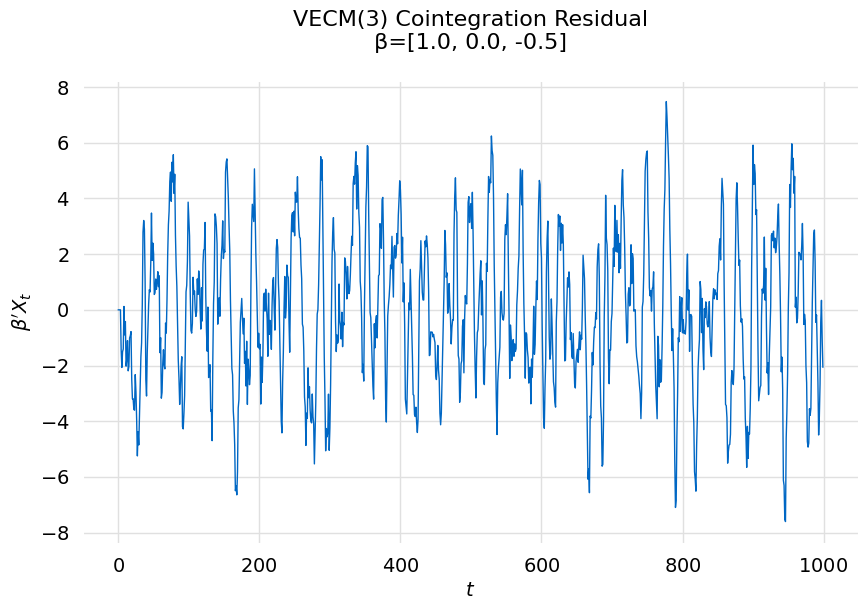

In [68]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(3) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [69]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -10.9449      │
├────────────────┼───────────────┤
│ pvalue         │   9.36281e-20 │
├────────────────┼───────────────┤
│ Lags           │   6           │
├────────────────┼───────────────┤
│ Number Obs     │ 993           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.568   │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


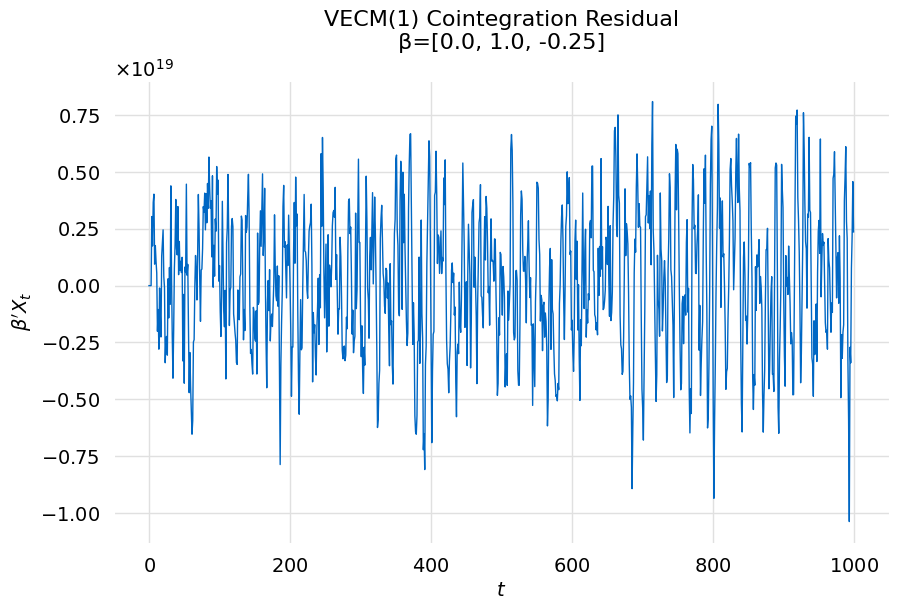

In [70]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [71]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -16.3884      │
├────────────────┼───────────────┤
│ pvalue         │   4.45483e-28 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
